In [1]:
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
from module.models import MLP, ResidualMLPClassifier
from torch.utils.data import DataLoader, Dataset
from module.dataset import PCLDataset
from module.metrics import computeMetrics

def getData(file_path, split_file_path):
    with open(file_path, 'r', encoding='utf-8') as file:
        data = file.readlines()

    data = [line.strip().split('\t') for line in data[4:]]
    data = [
        {
            "id": int(line[0]),
            "category": str(line[2]),
            "country": str(line[3]),
            "text": str(line[4]),
            "label": 1 if any(int(line[5]) == i for i in [2,3,4]) else 0
        }
        for line in data
    ]

    split_file = pd.read_csv(split_file_path).set_index("par_id")
    split_ids = set(split_file.index)
    
    data = [d for d in data if d["id"] in split_ids]
    return data

def getCategories(file_path, split_file_path):
    with open(file_path, 'r', encoding='utf-8') as file:
        data = file.readlines()

    data = [line.strip().split('\t') for line in data[4:]]
    # data = [
    #     {
    #         "id": int(line[0]),
    #         "category": str(line[-2]),
    #     }
    #     for line in data if len(line) > 0
    # ]
    categoryDic = {}
    for line in data:
        if len(line) < 0:
            continue
        id = int(line[0])
        category = str(line[-2])
        print(id, category)
        if id not in categoryDic:
            categoryDic[id] = [category]
        else:
            categoryDic[id].append(category)

    split_file = pd.read_csv(split_file_path).set_index("par_id")
    split_ids = set(split_file.index)
    
    # data = [d for d in data if d["id"] in split_ids]
    # data = {d["id"]: d["category"] for d in data if d["id"] in split_ids}
    data = {id: cats for id, cats in categoryDic.items() if id in split_ids}
    return data

In [2]:
model = ResidualMLPClassifier(4096, 2)
model.load_state_dict(torch.load("checkpoints/run/mlp_res_56_61_58.pt"))

<All keys matched successfully>

In [3]:
file_path = "data/NLPLabs-2024/Dont_Patronize_Me_Trainingset/dontpatronizeme_pcl.tsv"
category_path = "data/NLPLabs-2024/Dont_Patronize_Me_Trainingset/dontpatronizeme_categories.tsv"
split_file_path = "data/dontpatronizeme/semeval-2022/practice splits/dev_semeval_parids-labels.csv"

In [4]:
data = getData(
    file_path,
    split_file_path
)
id2categories = getCategories(
    category_path,
    split_file_path
)
# class PCLDataset(Dataset):
#     def __init__(self, load_path, return_embedding=True):
#         self.dataset = load_from_disk(load_path)
#         self.return_embedding = return_embedding
#         if self.return_embedding:
#             self.embeddings = np.load(os.path.join(load_path, "embeddings.npy"))
            
#     def __len__(self):
#         return len(self.dataset)

#     def __getitem__(self, idx):
#         item = self.dataset[idx]
#         if self.return_embedding:
#             return self.embeddings[idx], item["label"]
#         else:
#             return item["text"], item["label"]
class PCLDataset_analysis(PCLDataset):
    def __init__(self, load_path, return_embedding=True):
        super().__init__(load_path=load_path, return_embedding=return_embedding)
    
    def __getitem__(self, idx):
        item = self.dataset[idx]
        if self.return_embedding:
            return item["id"], self.embeddings[idx], item["label"]
        else:
            return item["id"], item["text"], item["label"]

4046 Authority_voice
4046 Unbalanced_power_relations
4046 Unbalanced_power_relations
4046 Authority_voice
4046 Unbalanced_power_relations
4046 Unbalanced_power_relations
1279 Shallow_solution
8330 Presupposition
4063 Compassion
4063 Metaphors
4063 Unbalanced_power_relations
4063 Compassion
4063 Metaphors
4063 Authority_voice
4089 Unbalanced_power_relations
4089 Unbalanced_power_relations
432 Compassion
432 Compassion
4177 Unbalanced_power_relations
4177 Compassion
3963 Unbalanced_power_relations
3963 Shallow_solution
3963 Compassion
2001 Presupposition
369 Presupposition
369 Presupposition
369 Compassion
369 Compassion
369 Unbalanced_power_relations
369 Authority_voice
369 Compassion
369 Compassion
369 Unbalanced_power_relations
369 Compassion
773 Compassion
773 Unbalanced_power_relations
773 Presupposition
6510 Compassion
6510 Unbalanced_power_relations
6510 Authority_voice
6510 Compassion
6510 Presupposition
6510 Shallow_solution
7394 Shallow_solution
7394 Unbalanced_power_relations


In [5]:
id2categories

{4046: ['Authority_voice',
  'Unbalanced_power_relations',
  'Unbalanced_power_relations',
  'Authority_voice',
  'Unbalanced_power_relations',
  'Unbalanced_power_relations'],
 1279: ['Shallow_solution'],
 8330: ['Presupposition'],
 4063: ['Compassion',
  'Metaphors',
  'Unbalanced_power_relations',
  'Compassion',
  'Metaphors',
  'Authority_voice'],
 4089: ['Unbalanced_power_relations', 'Unbalanced_power_relations'],
 432: ['Compassion', 'Compassion'],
 4177: ['Unbalanced_power_relations', 'Compassion'],
 3963: ['Unbalanced_power_relations', 'Shallow_solution', 'Compassion'],
 2001: ['Presupposition'],
 369: ['Presupposition',
  'Presupposition',
  'Compassion',
  'Compassion',
  'Unbalanced_power_relations',
  'Authority_voice',
  'Compassion',
  'Compassion',
  'Unbalanced_power_relations',
  'Compassion'],
 773: ['Compassion', 'Unbalanced_power_relations', 'Presupposition'],
 6510: ['Compassion',
  'Unbalanced_power_relations',
  'Authority_voice',
  'Compassion',
  'Presuppositi

In [6]:
pcldata = PCLDataset_analysis("data/processed/val_dataset", return_embedding=True)
pcldata_simple = PCLDataset("data/processed/val_dataset", return_embedding=True)

In [7]:
loader = DataLoader(pcldata, batch_size=32, shuffle=False)
loader_simple = DataLoader(pcldata_simple, 32, False)

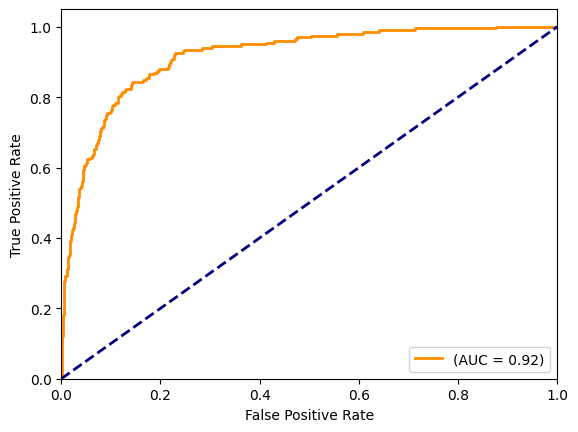

In [8]:
preds = []
final_labels = []
model.eval()
with torch.no_grad():
    for ids, embeddings, labels in loader:
        # print(ids)
        embeddings = embeddings.to(torch.float32)
        outputs = model(embeddings)
        preds_prob = F.softmax(outputs, dim=1)[:, 1]  # Get probability of class 1
        preds.extend(preds_prob.cpu().numpy())
        final_labels.extend(labels.cpu().numpy())

# plot roc curve
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
fpr, tpr, thresholds = roc_curve(final_labels, preds)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'(AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# plt.title('RoC Curve')
plt.legend(loc="lower right")
plt.show()


In [9]:
preds = []
final_labels = []
model.eval()
with torch.no_grad():
    for ids, embeddings, labels in loader:
        # print(ids)
        embeddings = embeddings.to(torch.float32)
        outputs = model(embeddings)
        predictions = torch.argmax(outputs, dim=1)
        preds.extend(predictions.cpu().numpy())
        final_labels.extend(labels.cpu().numpy())

# print f1 score
from sklearn.metrics import f1_score, confusion_matrix, classification_report
f1 = f1_score(final_labels, preds)
print(f"F1 Score: {f1:.4f}")
print("Classification Report:")
print(classification_report(final_labels, preds))

# save only predictions
with open("dev_predictions.txt", "w") as f:
    for pred in preds:
        f.write(f"{pred}\n")

F1 Score: 0.5851
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.95      0.95      1895
           1       0.56      0.61      0.59       199

    accuracy                           0.92      2094
   macro avg       0.76      0.78      0.77      2094
weighted avg       0.92      0.92      0.92      2094



In [10]:
device = torch.device("cpu")
metrics = computeMetrics(model, loader_simple, device)

In [11]:
metrics

{'Loss': 0.21207989368474844,
 'Accuracy': 0.9173829990448902,
 'Precision': 0.5596330275229358,
 'Recall': 0.6130653266331658,
 'F1 Score': 0.5851318944844124}

In [12]:
test_dataset = PCLDataset_analysis("data/processed/test_dataset_final", return_embedding=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

model.eval()
metrics = computeMetrics(model, loader_simple, device)
print(metrics)

predictions_test = []
model.eval()

with torch.no_grad():
    for ids, embeddings, labels in test_loader:
        # print(ids)
        embeddings = embeddings.to(torch.float32)
        outputs = model(embeddings)
        predictions = torch.argmax(outputs, dim=1)
        print(ids)
        predictions_test.extend(predictions.cpu().numpy())

# save predictions in a txt file
with open("test_predictions.txt", "w") as f:
    for pred in predictions_test:
        f.write(f"{pred}\n")

{'Loss': 0.21207989368474844, 'Accuracy': 0.9173829990448902, 'Precision': 0.5596330275229358, 'Recall': 0.6130653266331658, 'F1 Score': 0.5851318944844124}
tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
        19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32])
tensor([33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
        51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64])
tensor([65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82,
        83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 96, 97])
tensor([ 98,  99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111,
        112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125,
        126, 127, 128, 129])
tensor([130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143,
        144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157,
        158, 159, 160, 161])
tensor([162, 163, 164, 165, 166, 167, 

In [13]:
id2pred = {}
model.eval()
with torch.no_grad():
    for ids, embeddings, labels in loader:
        print(ids)
        embeddings = embeddings.to(torch.float32)
        outputs = model(embeddings)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        for id, pred in zip(ids, preds):
            id2pred[id.item()] = pred.item()

tensor([ 107,  149,  151,  154,  157,  187,  232,  350,  369,  432,  490,  498,
         582,  644,  650,  734,  773,  808,  823,  915,  952,  991, 1063, 1067,
        1090, 1137, 1200, 1208, 1279, 1283, 1301, 1381])
tensor([1447, 1477, 1572, 1648, 1674, 1693, 1790, 1834, 1847, 1870, 1922, 1961,
        2001, 2133, 2196, 2333, 2342, 2351, 2453, 2591, 2610, 2848, 2918, 2953,
        2956, 2959, 2984, 3025, 3047, 3130, 3211, 3213])
tensor([3265, 3297, 3382, 3605, 3614, 3661, 3672, 3716, 3861, 3910, 3963, 4023,
        4046, 4056, 4063, 4089, 4156, 4177, 4218, 4227, 4303, 4327, 4344, 4393,
        4494, 4538, 4560, 4580, 4684, 4710, 4802, 5059])
tensor([5072, 5248, 5252, 5367, 5442, 5497, 5506, 5512, 5552, 5593, 5612, 5685,
        5722, 5816, 5829, 5846, 5862, 5921, 5955, 5989, 5996, 6056, 6115, 6129,
        6189, 6234, 6260, 6266, 6309, 6392, 6428, 6510])
tensor([6546, 6645, 6646, 6681, 6690, 6699, 6708, 6731, 6821, 6852, 6873, 6907,
        6995, 7004, 7040, 7111, 7127, 7153, 7154, 71

In [14]:
from collections import defaultdict

def category_accuracy_analysis(data, id2pred):
    preds = {int(k): v for k, v in id2pred.items()}

    stats = defaultdict(lambda: {"tp":0,"fp":0,"fn":0,"tn":0})
    overall = {"tp":0,"fp":0,"fn":0,"tn":0}

    for d in data:
        idx = d["id"]
        if idx not in preds:
            print(f"ID {idx} not found in predictions")
            assert False, f"ID {idx} not found in predictions"
            # continue

        true = d["label"]
        pred = preds[idx]

        overall["tp"] += int(true==1 and pred==1)
        overall["fp"] += int(true==0 and pred==1)
        overall["fn"] += int(true==1 and pred==0)
        overall["tn"] += int(true==0 and pred==0)

        cats = id2categories.get(idx, ["Unknown"])

        for c in set(cats):
            stats[c]["tp"] += int(true==1 and pred==1)
            stats[c]["fn"] += int(true==1 and pred==0)

    print(f"{'Category':<25} | {'Count':<6} | {'Recall':<10}")
    print("-"*55)

    for cat in sorted(stats.keys()):
        s = stats[cat]
        tp,fp,fn,tn = s["tp"],s["fp"],s["fn"],s["tn"]
        # print recall only
        print(f"{cat:<25} | {tp+fn:<6} | {(tp/(tp+fn) if (tp+fn)>0 else 0):.3f}")

    tp,fp,fn = overall["tp"],overall["fp"],overall["fn"]
    overall_f1 = (2*tp)/(2*tp+fp+fn) if (2*tp+fp+fn)>0 else 0

    print("\nOverall F1:", round(overall_f1,3))

category_accuracy_analysis(data, id2pred)

Category                  | Count  | Recall    
-------------------------------------------------------
Authority_voice           | 38     | 0.658
Compassion                | 106    | 0.660
Metaphors                 | 52     | 0.654
Presupposition            | 62     | 0.532
Shallow_solution          | 36     | 0.694
The_poorer_the_merrier    | 11     | 0.364
Unbalanced_power_relations | 142    | 0.627
Unknown                   | 0      | 0.000

Overall F1: 0.585


In [15]:
from sklearn.metrics import f1_score
gts = [data[i]["label"] for i in range(len(data))]
preds = [id2pred[data[i]["id"]] for i in range(len(data))]

f1 = f1_score(gts, preds)

/opt/anaconda3/envs/iml/lib/python3.13/site-packages/sklearn/utils/extmath.py:374: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/opt/anaconda3/envs/iml/lib/python3.13/site-packages/sklearn/utils/extmath.py:374: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/opt/anaconda3/envs/iml/lib/python3.13/site-packages/sklearn/utils/extmath.py:374: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/opt/anaconda3/envs/iml/lib/python3.13/site-packages/sklearn/utils/extmath.py:375: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/opt/anaconda3/envs/iml/lib/python3.13/site-packages/sklearn/utils/extmath.py:375: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/opt/anaconda3/envs/iml/lib/python3.13/site-packages/sklearn/utils/extmath.py:375: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/opt/anaconda3/envs/iml/lib/py

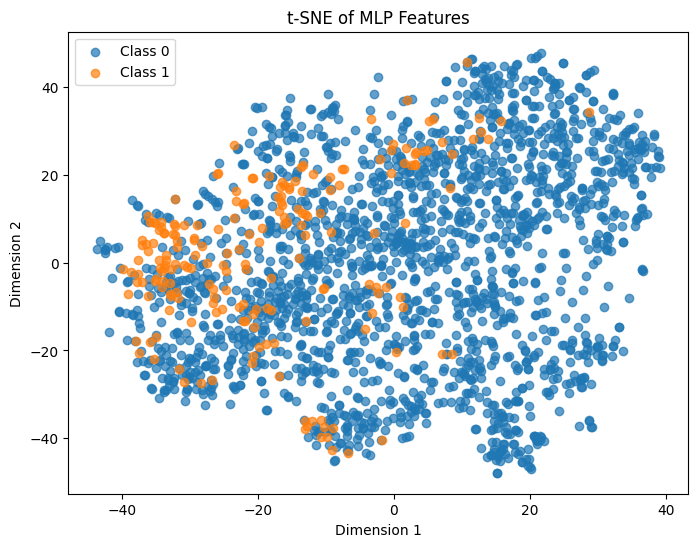

/opt/anaconda3/envs/iml/lib/python3.13/site-packages/sklearn/utils/extmath.py:374: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/opt/anaconda3/envs/iml/lib/python3.13/site-packages/sklearn/utils/extmath.py:374: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/opt/anaconda3/envs/iml/lib/python3.13/site-packages/sklearn/utils/extmath.py:374: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/opt/anaconda3/envs/iml/lib/python3.13/site-packages/sklearn/utils/extmath.py:375: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/opt/anaconda3/envs/iml/lib/python3.13/site-packages/sklearn/utils/extmath.py:375: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/opt/anaconda3/envs/iml/lib/python3.13/site-packages/sklearn/utils/extmath.py:375: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/opt/anaconda3/envs/iml/lib/py

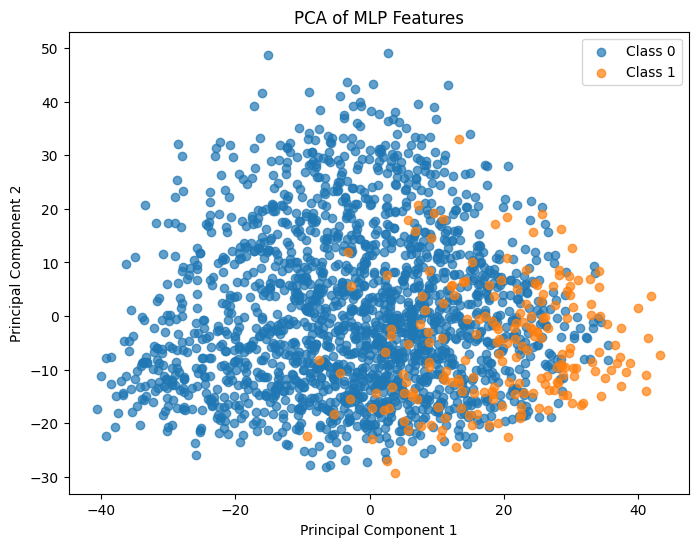

In [16]:
embeddings_plot = []
labels_all = []

model.eval()

with torch.no_grad():
    for batch in loader_simple:
        embeddings, labels = batch
        embeddings = embeddings.to(device)

        features = model.features(embeddings)

        embeddings_plot.append(features.cpu().numpy())
        labels_all.append(labels.numpy())

embeddings_plot = np.concatenate(embeddings_plot, axis=0)
labels_all = np.concatenate(labels_all, axis=0)


from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

tsne = TSNE(n_components=2, random_state=42)
embeddings_2d = tsne.fit_transform(embeddings_plot)

plt.figure(figsize=(8,6))

for cls in np.unique(labels_all):
    idx = labels_all == cls
    plt.scatter(
        embeddings_2d[idx, 0],
        embeddings_2d[idx, 1],
        label=f"Class {cls}",
        alpha=0.7
    )

plt.legend()
plt.title("t-SNE of MLP Features")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.show()


from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
embeddings_scaled = scaler.fit_transform(embeddings_plot)

pca = PCA(n_components=2)
embeddings_2d_pca = pca.fit_transform(embeddings_scaled)

plt.figure(figsize=(8,6))

for cls in np.unique(labels_all):
    idx = labels_all == cls
    plt.scatter(
        embeddings_2d_pca[idx, 0],
        embeddings_2d_pca[idx, 1],
        label=f"Class {cls}",
        alpha=0.7
    )

plt.legend()
plt.title("PCA of MLP Features")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()